In [16]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
def conv2(img, conv_filter):
    # flip the filter
    f_siz_1, f_size_2 = conv_filter.shape
    conv_filter = conv_filter[range(f_siz_1 - 1, -1, -1), :][:, range(f_siz_1 - 1, -1, -1)]
    pad = (conv_filter.shape[0] - 1) // 2
    result = np.zeros((img.shape))
    img = np.pad(img, ((pad, pad), (pad, pad)), 'constant', constant_values=(0, 0))
    filter_size = conv_filter.shape[0]
    for r in np.arange(img.shape[0] - filter_size + 1):
        for c in np.arange(img.shape[1] - filter_size + 1):
            curr_region = img[r:r + filter_size, c:c + filter_size]
            curr_result = curr_region * conv_filter
            conv_sum = np.sum(curr_result)  # Summing the result of multiplication.
            result[r, c] = conv_sum  # Saving the summation in the convolution layer feature map.

    return result

In [17]:
def fspecial(shape=(3, 3), sigma=0.5):#get gussian filter
    m, n = [(ss - 1.) / 2. for ss in shape]#the coodinate of the center in matrix
    y, x = np.ogrid[-m:m + 1, -n:n + 1]
    h = np.exp(-(x * x + y * y) / (2. * sigma * sigma))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h

def Harris_cornerness(bw: np.ndarray, sigma: float, k: float, dx: np.ndarray, dy: np.ndarray) -> np.ndarray:
    """
    Calculates Harris corner response function for a grayscale image.
    
    Args:
        bw (numpy.ndarray): The grayscale input image.
        sigma (float): The standard deviation of the Gaussian filter.
        k (float): Empirical constant in the Harris corner response function.
        dx (numpy.ndarray): Derivative kernel in x-direction.
        dy (numpy.ndarray): Derivative kernel in y-direction.

    Returns:
        numpy.ndarray: The Harris corner response function.

    """

In [26]:
######################################################################
# Task: Compute the Harris Cornerness
######################################################################
#sigma is the standard deviation of Gaussian filtering, thresh is the threshold of the corner response function, 
#k is the response function coefficient, and block_size is the window size used to calculate the corner response function.
#The ksize parameter in this function represents the size of the Sobel operator kernel used for calculating gradients in the x and y directions. 
sigma = 2
thresh = 0.01
k = 0.05
block_size = 5
ksize = 3
#Define two convolution kernels dx and dy, which are used to calculate the gradient value of pixels in the image.
#dx is the convolution kernel for derivation in the horizontal direction, and dy is the convolution kernel for derivation in the vertical direction. 
#They can be used to calculate the gradient values in the x and y directions of each pixel in the image.
matrix = np.array([
    [0, -5, -2,  2,  8],
    [1,  5, -3,  1, 10],
    [4, -2,  6,  3,  3],
    [0, -3, -2,  0,-10],
    [-7,-8,  2, -4, -8]
])
dx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
dy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

def Harris_cornerness(bw, sigma, k, dx, dy):
    #Use the fspecial function defined previously to generate a Gaussian filter g.
    g = fspecial((max(1, np.floor(3 * sigma) * 2 + 1), max(1, np.floor(3 * sigma) * 2 + 1)), sigma)
    #Compute the gradient images Ix and Iy of the input image bw in the x and y directions 
    #using the convolution operation with the kernels dx and dy.
    Ix = conv2(bw, dx)
    Iy = conv2(bw, dy)
    #3)	Compute the three values Iy2, Ix2, and Ixy using the Harris corner detection algorithm formula, 
    #which will be used to calculate the corner response function.
    Iy2 = conv2(np.power(Iy, 2), g)
    Ix2 = conv2(np.power(Ix, 2), g)
    Ixy = conv2(Ix * Iy, g)
    print(Ix2)
    print(Iy2)
    print(Ixy)
    #caculate R
    #k is empirical constant, k =0.01-0.1.We have set k as 0.04 above
    #det(M)=λ1λ2
    #trace(M)=λ1+λ2
    #λ1 and λ2 are the eigenvalues of  M
    det_M = Ix2 * Iy2 - np.power(Ixy, 2)
    trace_M = Ix2 + Iy2
    R = det_M - k * np.power(trace_M, 2)
    return R

def non_max_suppression(image: np.ndarray, window_size: int, thresh: float) -> np.ndarray:
    """
    Apply non-maximum suppression to the corner response image to obtain the corner coordinates.

    Args:
    - image: 2D array representing the corner response image.
    - window_size: integer representing the size of the window to find local maximum values.
    - thresh: float representing the threshold value to filter out weak corners.

    Returns:
    - corners: 2D array of (x, y) coordinates representing the detected corner points.
    """

In [27]:
######################################################################
# Task: Perform non-maximum suppression and
#       thresholding, return the N corner points
#       as an Nx2 matrix of x and y coordinates
######################################################################
def non_max_suppression(image, window_size, thresh):
    #h and w represent the height and width of the corner response function image respectively
    h, w = image.shape
    #half of window size, used to find the Pixel-centered window
    offset = window_size // 2
    corner_list = []
    # Double cycle through the pixels of the entire image, where window represents the local window around the current pixel;
    #By comparing the value of the current pixel point with the maximum value in the surrounding window, 
    #determine whether the current pixel point is greater than thresh, if so, add its coordinates to the corner_list
    for y in range(offset, h - offset):
        for x in range(offset, w - offset):
            window = image[y-offset:y+offset+1, x-offset:x+offset+1]
            if image[y, x] == np.max(window) and image[y, x] >= thresh*np.max(image):
                corner_list.append((x, y))
    return np.array(corner_list)

In [28]:
R = Harris_cornerness(matrix,sigma, k, dx, dy)
R

[[ 50.9134325   81.83679605 108.30324293 115.89033338  99.015491  ]
 [ 66.25245461 102.45770376 132.12020814 139.1001235  117.69845505]
 [ 77.198264   114.11927443 142.43892227 146.77872892 122.54586007]
 [ 79.9833994  113.37590246 136.95928121 137.96407964 113.5106254 ]
 [ 71.62906286  98.30073839 115.60135618 114.20171007  92.75572003]]
[[ 76.72650248 105.37543511 127.34941087 134.85315019 122.59874815]
 [111.828529   152.70217442 183.67333458 193.70990635 175.44661237]
 [135.10024898 183.43340473 219.61962062 230.72989002 208.24679339]
 [134.09897832 181.16771982 215.99424424 226.10021811 203.39205709]
 [108.31422001 145.82930672 173.33580878 180.94266622 162.33307027]]
[[ 6.29143464 12.66048574 20.86091479 26.60045202 26.03413325]
 [11.17759071 18.65303801 28.34980404 35.44954946 34.94682241]
 [15.58706079 22.85227694 32.24937271 39.38510359 38.91390744]
 [17.09907632 22.9117763  30.29707303 36.06288519 35.58415031]
 [14.7587397  18.52961331 23.13693279 26.81737433 26.38600092]]


array([[ 3052.22980506,  6710.87911736, 10580.56775469, 11776.97775788,
         9005.75559986],
       [ 5698.33417096, 12042.25015208, 18476.96972475, 20150.27554068,
        15131.81329508],
       [ 7933.01529303, 15984.18064893, 23688.04060681, 25189.41572757,
        18534.30123084],
       [ 8141.7505081 , 15677.30696695, 22435.6942468 , 23266.03616517,
        16799.56234081],
       [ 5921.64642381, 11011.8080138 , 15328.30264514, 15589.28019785,
        11107.58522578]])

AttributeError: 'NoneType' object has no attribute 'shape'

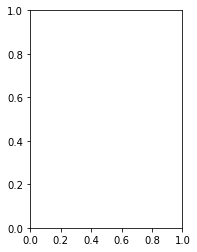

In [29]:
#image1
#without normalise
#my result
fig = plt.figure()
ax = fig.add_subplot(121)
bw_1 = cv2.imread('Task1/Harris-1.jpg', cv2.IMREAD_GRAYSCALE)
R = Harris_cornerness(bw_1,sigma, k, dx, dy)
corner_points = non_max_suppression(R,block_size,thresh)
ax.set_title("Image1 of mine")
ax.imshow(bw_1, cmap='gray')
ax.plot(corner_points[:, 0], corner_points[:, 1], 'r.', markersize=3)
ax2 = fig.add_subplot(122)
#built-in result
# get cornerHarris
dst = cv2.cornerHarris(bw_1, block_size, ksize, k)
corner_points = non_max_suppression(dst,block_size,thresh)
ax2.set_title("Image1 of built-in")
ax2.imshow(bw_1, cmap='gray')
ax2.plot(corner_points[:, 0], corner_points[:, 1], 'r.', markersize=3)

AttributeError: 'NoneType' object has no attribute 'shape'

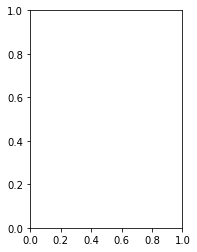

In [22]:
#image2 of my f
fig = plt.figure()
ax = fig.add_subplot(121)
bw_2 = cv2.imread('Task1/Harris-2.jpg', cv2.IMREAD_GRAYSCALE)
R = Harris_cornerness(bw_2,sigma, k, dx, dy)
corner_points = non_max_suppression(R,block_size,thresh)
ax.set_title("Image2 of mine")
ax.imshow(bw_2, cmap='gray')
ax.plot(corner_points[:, 0], corner_points[:, 1], 'r.', markersize=3)
ax2 = fig.add_subplot(122)
# 进行角点检测
dst = cv2.cornerHarris(bw_2, block_size, ksize, k)
# 标记角点
corner_points = non_max_suppression(dst,block_size,thresh)
ax2.set_title("Image2 of built-in")
ax2.imshow(bw_2, cmap='gray')
ax2.plot(corner_points[:, 0], corner_points[:, 1], 'r.', markersize=3)

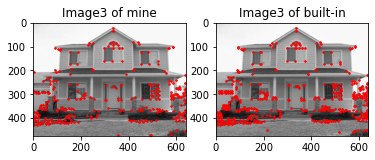

In [7]:
#image3 of my f
fig = plt.figure()
ax = fig.add_subplot(121)
bw_3 = cv2.imread('Task1/Harris-3.jpg', cv2.IMREAD_GRAYSCALE)
R = Harris_cornerness(bw_3,sigma, k, dx, dy)
corner_points = non_max_suppression(R,block_size,thresh)
ax.set_title("Image3 of mine")
ax.imshow(bw_3, cmap='gray')
ax.plot(corner_points[:, 0], corner_points[:, 1], 'r.', markersize=3)
ax2 = fig.add_subplot(122)
# 进行角点检测
dst = cv2.cornerHarris(bw_3, block_size, ksize, k)
# 标记角点
corner_points = non_max_suppression(dst,block_size,thresh)
ax2.set_title("Image3 of built-in")
ax2.imshow(bw_3, cmap='gray')
ax2.plot(corner_points[:, 0], corner_points[:, 1], 'r.', markersize=3)

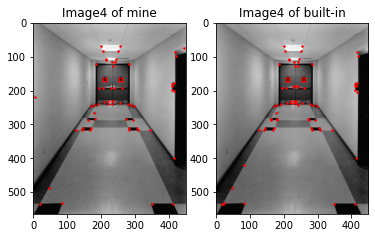

In [8]:
#image4 of my f
fig = plt.figure()
ax = fig.add_subplot(121)
bw_4 = cv2.imread('Task1/Harris-4.jpg', cv2.IMREAD_GRAYSCALE)
R = Harris_cornerness(bw_4,sigma, k, dx, dy)
corner_points = non_max_suppression(R,block_size,thresh)
ax.set_title("Image4 of mine")
ax.imshow(bw_4, cmap='gray')
ax.plot(corner_points[:, 0], corner_points[:, 1], 'r.', markersize=3)
ax2 = fig.add_subplot(122)
# 进行角点检测
dst = cv2.cornerHarris(bw_4, block_size, ksize, k)
# 标记角点
corner_points = non_max_suppression(dst,block_size,thresh)
ax2.set_title("Image4 of built-in")
ax2.imshow(bw_4, cmap='gray')
ax2.plot(corner_points[:, 0], corner_points[:, 1], 'r.', markersize=3)

In [9]:
    """
    Applies inverse image warping to the input image using the inverse transformation matrix,
    and returns the transformed image of the specified output size.
    
    Args:
        input_image: the input image to be transformed
        inv_transform: the inverse transformation matrix to be applied
        output_size: the size of the output image
        
    Returns:
        transformed_image: the transformed output image
    """

'\nApplies inverse image warping to the input image using the inverse transformation matrix,\nand returns the transformed image of the specified output size.\n\nArgs:\n    input_image: the input image to be transformed\n    inv_transform: the inverse transformation matrix to be applied\n    output_size: the size of the output image\n    \nReturns:\n    transformed_image: the transformed output image\n'

In [1]:
from PIL import Image

def inverse_warp(input_image, inv_transform, output_size):
    # Get the width and height of the input image
    input_width, input_height = input_image.size
    # create a object as output
    transformed_img = Image.new(input_image.mode, output_size)
    #calculate the new pixel after transform
    inv_transform = np.linalg.inv(inv_transform)
    for y_transformed in range(output_size[1]):
        for x_transformed in range(output_size[0]):
            #(x_transformed, y_transformed) converted to homogeneous coordinate form (x_transformed, y_transformed, 1)
            transformed_point = np.array([x_transformed, y_transformed, 1])
            #Calculate the homogeneous coordinates (x_input, y_input, w_input) in the corresponding pre-transformed image 
            #by solving the product of the matrix inv_transform and the homogeneous coordinates (x_transformed, y_transformed, 1)
            input_point = np.dot(inv_transform, transformed_point)
            #w_input represents the scaling factor in homogeneous coordinates. Finally, divide x_input and y_input by w_input
            x_input, y_input = input_point[:2] / input_point[2]
            # If the coordinates in the transformed image are within the range of the transformed image, perform bilinear interpolation to calculate the pixel value
            if x_input >= 0 and x_input < input_width - 1 and y_input >= 0 and y_input < input_height - 1:
                x1 = int(x_input)
                #Calculate the corresponding coordinates in the pre-transformed image based on the transformed coordinates
                y1 = int(y_input)
                x2 = x1 + 1
                y2 = y1 + 1
                dx = x_input - x1
                dy = y_input - y1
                #Get the pixel values of four adjacent pixels
                pixel_value_00 = input_image.getpixel((x1, y1))
                pixel_value_01 = input_image.getpixel((x1, y2))
                pixel_value_10 = input_image.getpixel((x2, y1))
                pixel_value_11 = input_image.getpixel((x2, y2))
                #Calculate the pixel value by bilinear interpolation based on the values of the four pixels and the offset of the transformed coordinates
                pixel_value = (
                    (1 - dx) * (1 - dy) * pixel_value_00[0] + dx * (1 - dy) * pixel_value_10[0] + (1 - dx) * dy * pixel_value_01[0] + dx * dy * pixel_value_11[0],
                    (1 - dx) * (1 - dy) * pixel_value_00[1] + dx * (1 - dy) * pixel_value_10[1] + (1 - dx) * dy * pixel_value_01[1] + dx * dy * pixel_value_11[1],
                    (1 - dx) * (1 - dy) * pixel_value_00[2] + dx * (1 - dy) * pixel_value_10[2] + (1 - dx) * dy * pixel_value_01[2] + dx * dy * pixel_value_11[2]
                )
                
                # Set the calculated pixel values into the new image
                transformed_img.putpixel((x_transformed, y_transformed), (int(pixel_value[0]), int(pixel_value[1]), int(pixel_value[2])))
    
    return transformed_img

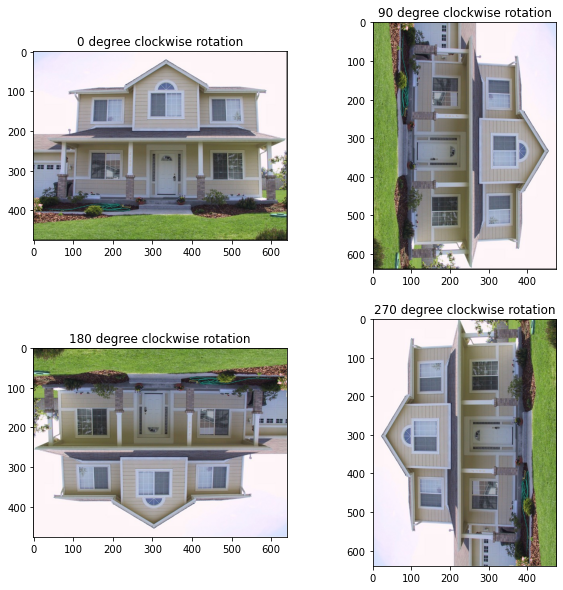

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load input image
input_image = Image.open("Task1/Harris-3.jpg")

# Define rotation angles
rotation_angles = [0, 90, 180, 270]

# Define figure and subplots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
axs = axs.flatten()
rotate_image = []
# Loop over rotation angles
for i, angle in enumerate(rotation_angles):
    # Define transformation matrix for current angle
    transform = None
    if angle == 0:
        transform = np.array([[1, 0, 0],
                              [0, 1, 0],
                              [0, 0, 1]])
    elif angle == 90:
        transform = np.array([[0, 1, 0],
                              [-1, 0, input_image.size[1]-1],
                              [0, 0, 1]])
    elif angle == 180:
        transform = np.array([[-1, 0, input_image.size[0]-1],
                              [0, -1, input_image.size[1]-1],
                              [0, 0, 1]])
    elif angle == 270:
        transform = np.array([[0, -1, input_image.size[0]-1],
                              [1, 0, 0],
                              [0, 0, 1]])
    else:
        raise ValueError("Invalid angle specified.")

    # Define output size for rotated image
    inv_transform = np.linalg.inv(transform)
    output_size = (input_image.size[1], input_image.size[0]) if angle in [90, 270] else (input_image.size[0], input_image.size[1])

    # Apply inverse image warping to rotate the image
    rotated_image = inverse_warp(input_image, inv_transform, output_size)
    rotate_image.append(rotated_image)

    # Display the rotated image
    axs[i].set_title(f"{angle} degree clockwise rotation")
    axs[i].imshow(rotated_image)

# Show the figure
plt.show()

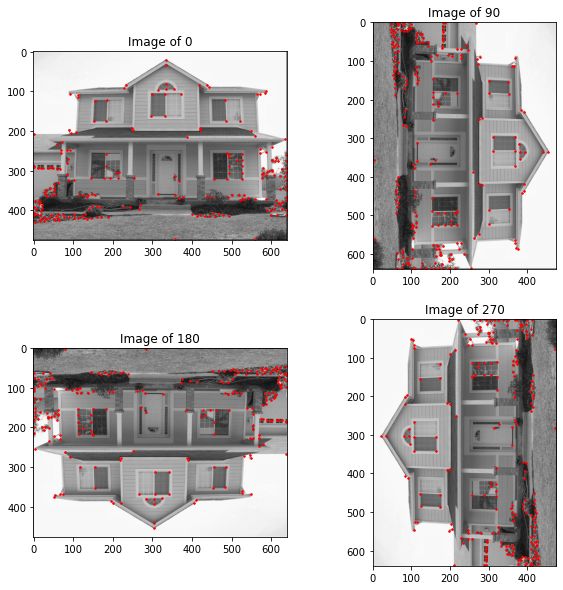

In [14]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

for i, ax in enumerate(axs.flat):
    # Get the corresponding image and angle
    gray_image = rotate_image[i].convert('L')
    angle = i * 90
    
    # Compute corner points using Harris corner detector and non-maximum suppression
    R = Harris_cornerness(np.array(gray_image), sigma, k, dx, dy)
    corner_points = non_max_suppression(R, block_size, thresh)
    
    # Set the subplot title and plot the corner points
    ax.set_title(f"Image of {angle}")
    ax.imshow(gray_image, cmap='gray')
    ax.plot(corner_points[:, 0], corner_points[:, 1], 'r.', markersize=3)